In [112]:
# ! brew install ollama
# ! ollama serve
# ! ollama pull llama3:8b
! ollama list

NAME         ID              SIZE      MODIFIED       
llama3:8b    365c0bd3c000    4.7 GB    14 minutes ago    


## Open model (Llama)

In [113]:
# User-inputted variables
START_LAT = 32.5106
START_LON = -117.0626 
NUM_POIS_TO_VISIT = 4
TIME_PER_POI = 1.5
MAX_DIST = 15

# User Preferences
USER_PREFERENCES = {
    "start_location": {"lat": START_LAT, "lon": START_LON},
    "num_poi": NUM_POIS_TO_VISIT,
    "time_per_poi": TIME_PER_POI,
    "max_travel_dist": MAX_DIST,
    "avg_travel_speed_mph": 20.0, 
    "max_travel_time_minutes": 45.0,
    "amenity_type": "restaurant|theatre|cafe", #'fast_food', 'restaurant', 'cafe', 'post_office', 'fountain', 'bench', 'theatre', 'clock', 'bicycle_parking', 'planetarium', 'conference_centre', 'fire_station', 'cinema', 'toilets', 'arts_centre', 'place_of_worship'
    "tourism_type": "museum|gallery|viewpoint|attraction|aquarium", # 'attraction', 'gallery', 'museum', 'viewpoint', 'artwork', 'aquarium', 'zoo', 'theme_park'
    "cuisine": "italian|mexican|american",
    "required_accessibility": "wheelchair", #"wheelchair|toilets:wheelchair"
    "visited_ids": set()
}

In [114]:
import subprocess
import json
import re


def run_ollama(prompt, model="llama3:8b"):
    result = subprocess.run(
        ["ollama", "run", model, "--format", "json"],
        input=prompt,
        encoding="utf-8",
        capture_output=True
    )
    return result.stdout


In [115]:
def create_prompt(pref):

  prompt = f"""
  You are an travel planner that specializes in accessible tourism.

  Task:
  Generate a one-day itinerary in San Diego for a user with limited mobility,
  based on the following user preferences:

  {pref}

  Guidelines:
  - The itinerary should include exactly 4 stops.
  - Total Travel Time should not exceed 60 minutes.
  - The route should be feasible for one day (~8–10 hours total).
  - Assume the user uses a wheelchair — prefer locations that are likely accessible.
  - Try to balance sightseeing and dining activities.
  - Order stops from morning to evening.
  - Include an approximate visiting time for each stop.

  Output format:
  Return JSON only. No explanations, markdown, or text outside JSON.
  The output must start with '[' and end with ']'.

  [
    {{
      "id": int,                // from candidate; must be in CANDIDATE_IDS
      "name": str,              // copy verbatim from candidate
      "lat": float,             // copy verbatim from candidate
      "lon": float,             // copy verbatim from candidate
      "poi_type": "amenity" | "tourism",   // copy verbatim from candidate
      "features": "wheelchair",  // copy verbatim from candidate
      "amenity" : str,          // copy verbatim if present; else omit or set "" only if absent
      "tourism" : str,          // copy verbatim if present; else omit or set "" only if absent
      "cuisine": str            // copy verbatim if present; else ""
    }},
    ...
  ]

  The output style must be like example output:
  {{ "data":
    [
        {{"id": 1, "name": "Tiger Coffee", "lat": 34.04, "lon": -118.26, "poi_type": "amenity", 
        "features": {{"wheelchair": True, "toilets:wheelchair": True, "air_conditioning": True}},
        "amenity": "cafe", "cuisine": "italian"}}, 
        
        {{"id": 2, "name": "History Museum", "lat": 34.07, "lon": -118.23, "poi_type": "tourism", 
        "features": {{"wheelchair": True, "toilets:wheelchair": True, "air_conditioning": True}},
        "tourism": "museum"}},
        
        {{"id": 3, "name": "Sculpture Garden", "lat": 34.03, "lon": -118.28, "poi_type": "tourism", 
        "features": {{"wheelchair": True, "toilets:wheelchair": False, "air_conditioning": False}},
        "tourism": "artwork"}}, 

        {{"id": 4, "name": "Pasta Palace", "lat": 34.05, "lon": -118.25, "poi_type": "amenity", 
        "features": {{"wheelchair": True, "toilets:wheelchair": True, "air_conditioning": True}},
        "amenity": "restaurant", "cuisine": "italian"}}
    ]
  }}
  """

  return prompt


In [116]:
prompt = create_prompt(USER_PREFERENCES)
response = run_ollama(prompt)

In [117]:
raw_text = response.strip()

response_dict = re.sub(r'\btrue\b', 'True', raw_text, flags=re.IGNORECASE)
response_dict = re.sub(r'\bfalse\b', 'False', response_dict, flags=re.IGNORECASE)
response_dict = re.sub(r'\bnull\b', 'None', response_dict, flags=re.IGNORECASE)

In [118]:
response_dict = eval(response_dict)
print(response_dict)

{'data': [{'id': 1, 'name': 'USS Midway Museum', 'lat': 32.7066, 'lon': -117.1734, 'poi_type': 'tourism', 'features': {'wheelchair': True}, 'tourism': 'museum'}, {'id': 2, 'name': "Anthony's Fish Grotto", 'lat': 32.7077, 'lon': -117.1716, 'poi_type': 'amenity', 'features': {'wheelchair': True}, 'amenity': 'restaurant', 'cuisine': 'american'}, {'id': 3, 'name': 'The Old Globe', 'lat': 32.7111, 'lon': -117.1739, 'poi_type': 'tourism', 'features': {'wheelchair': True}, 'tourism': 'theatre'}, {'id': 4, 'name': 'Buona Forchetta', 'lat': 32.7105, 'lon': -117.1721, 'poi_type': 'amenity', 'features': {'wheelchair': True}, 'amenity': 'cafe', 'cuisine': 'italian'}]}


In [119]:
itinerary = [
{'id': 1, 'name': "America's Cup Harbor", 'lat': 32.5106, 'lon': -117.0626, 'poi_type': 'tourism', 'features': {'wheelchair': True, 'toilets:wheelchair': False, 'air_conditioning': False}, 'amenity': '', 'cuisine': ''}, {'id': 2, 'name': "Little Italy's Piazza Basilone", 'lat': 32.7103, 'lon': -117.1639, 'poi_type': 'tourism', 'features': {'wheelchair': True, 'toilets:wheelchair': False, 'air_conditioning': False}, 'tourism': 'viewpoint'}, {'id': 3, 'name': "Lamb's Players Theatre", 'lat': 32.6941, 'lon': -117.1579, 'poi_type': 'amenity', 'features': {'wheelchair': True, 'toilets:wheelchair': False, 'air_conditioning': False}, 'amenity': 'theatre'}, {'id': 4, 'name': 'The Patio on Lamont Street', 'lat': 32.6952, 'lon': -117.1588, 'poi_type': 'amenity', 'features': {'wheelchair': True, 'toilets:wheelchair': False, 'air_conditioning': False}, 'amenity': 'cafe', 'cuisine': 'mexican'}
]

In [120]:
itinerary = response_dict['data']

In [132]:
def run_ollama_encased(prompt):
    response = run_ollama(prompt)
    raw_text = response.strip()

    response_clean = raw_text.replace('True', 'true')
    response_clean = response_clean.replace('False', 'false')
    response_clean = response_clean.replace('None', 'null')
    
    try:
        response_dict = json.loads(response_clean)
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON response: {e}")
        print(f"Problematic string: {response_clean}") 
        return None
    
    itinerary = response_dict.get('data') 
    
    return itinerary

In [122]:
from evaluation import get_evaluation_metrics_verbose, get_evaluation_metrics

metrics = get_evaluation_metrics_verbose(itinerary, USER_PREFERENCES)


--------------------------------------------------------------------------------
Itinerary
--------------------------------------------------------------------------------
Total POIs: 4
User Preferences: {'start_location': {'lat': 32.5106, 'lon': -117.0626}, 'num_poi': 4, 'time_per_poi': 1.5, 'max_travel_dist': 15, 'avg_travel_speed_mph': 20.0, 'max_travel_time_minutes': 45.0, 'amenity_type': 'restaurant|theatre|cafe', 'tourism_type': 'museum|gallery|viewpoint|attraction|aquarium', 'cuisine': 'italian|mexican|american', 'required_accessibility': 'wheelchair', 'visited_ids': set()}
Required Features: wheelchair

--------------------------------------------------------------------------------
Quality of POI Metric
--------------------------------------------------------------------------------
Total Travel Distance: 15.51 miles
Total Travel Time: 46.5 minutes (Max: 45.0 min)
Travel Distance/Time Score: -0.03
POI Diversity Score: 0.50
Preference Coverage: 0.75

--------------------------

## Using Test Data

In [133]:
import json

test_filename = '../testing/user_preferences_100.json'
with open(test_filename, 'r', encoding='utf-8') as f:
    test_set = json.load(f)

itinerary_metrics = []
itinerary_metrics_success = []

for user_pref in test_set:
    user_pref['visited_ids'] = set()
    itinerary = run_ollama_encased(create_prompt(user_pref))

    metrics = get_evaluation_metrics(itinerary, user_pref)
    itinerary_metrics.append(metrics)
    if sum(metrics) != 0:
        itinerary_metrics_success.append(metrics)

## Visualization

[-2.616919703562732, 0.5275, 0.6975, 0.9925, 0.9925]


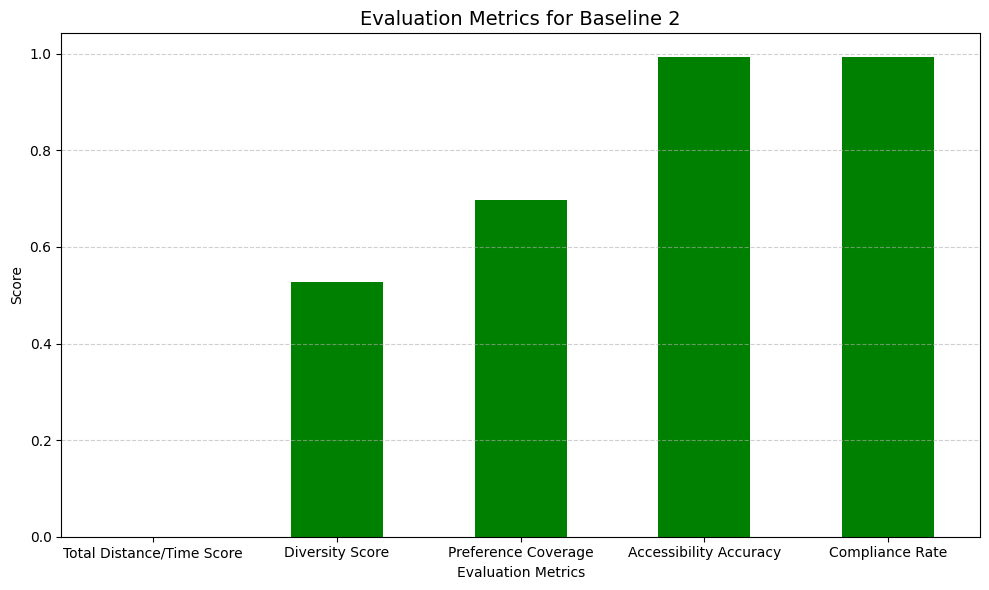

In [147]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(itinerary_metrics)
avg = df.mean(axis=0)
avg = avg.drop(index=[1, 2])

# < 0 means infeasible
if avg[0] < 0:
    print(list(avg))
    avg[0] = 0

labels = ['Total Distance/Time Score', 'Diversity Score', 'Preference Coverage', 'Accessibility Accuracy', 'Compliance Rate']

plt.figure(figsize=(10, 6))
ax = avg.plot(kind='bar', color='green')
ax.set_xticklabels(labels)
plt.title('Evaluation Metrics for Baseline 2', fontsize=14)
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()